In [1]:
import pandas as pd
import numpy as np
import re

<h3>Upload Data</h3>

In [2]:
master_roster = pd.read_csv("rosters_2020_2025.csv")
acs = pd.read_csv('acs_income_clean.csv')

In [3]:
master_roster.head(1)

,Team (College/University),Name,City,State,State ABBR,Country,High School,Season
0,Abilene Christian,Kamryn Mraz,Little River,Texas,TX,USA,Academy HS,2020-2021


In [4]:
acs.head(1)

,State,City,Median Household Income,Poverty Rate,Population (aged 15-19),Female Percentage,White (Non-Hispanic),Black (Non-Hispanic),American Indian/Alaskan Native (Non-Hispanic),Asian (Non-Hispanic),Hispanic
0,Alabama,Abanda,0.0,0.0,0,43.8,100.0,0.0,0.0,0.0,0.0


extra cleaning

In [5]:
import re

def remove_suffix(text):
    if pd.isna(text): return text
    clean_text = str(text)
    
    census_suffixes = [
        r'\s+city.*', r'\s+village.*', r'\s+town.*', r'\s+borough.*', 
        r'\s+township.*', r'\s+charter township.*', r'\s+plantation.*',
        r'\s+CDP.*', r'\s+comunidad.*', r'\s+zona urbana.*',
        r'\s+government.*', r'\s+municipality.*', r'\s+precinct.*',
        r'\s+gore.*', r'\s+grant.*', r'\s+location.*', r'\s+UT.*'
    ]
    for s in census_suffixes:
        clean_text = re.sub(s, '', clean_text)
        
    prefixes = [r'metropolitan government', r'consolidated government']
    for p in prefixes:
        clean_text = re.sub(p, '', clean_text, flags=re.IGNORECASE)

    clean_text = re.sub(r'/.*', '', clean_text)
    clean_text = re.sub(r'\(.*\)', '', clean_text)
    
    return clean_text.strip()

acs['City'] = acs['City'].apply(remove_suffix)

In [6]:
acs['City'] = acs['City'].apply(remove_suffix)
acs['State'] = acs['State'].apply(lambda x: str(x).split(',')[-1].strip())

In [7]:
for dataframe in [master_roster, acs]:
    dataframe['City'] = dataframe['City'].astype(str).str.replace('.', '', regex=False).str.replace('-', ' ', regex=False)
    dataframe['City'] = dataframe['City'].str.title().str.strip()
    dataframe['State'] = dataframe['State'].str.title().str.strip()

In [8]:
boroughs = ['Brooklyn', 'Bronx', 'Staten Island', 'Queens', 'Manhattan', 'Long Island']
master_roster.loc[master_roster['City'].isin(boroughs), 'City'] = 'New York'

<h3>Merge</h3>

In [9]:
df = pd.merge(master_roster, acs, on=['City','State'], how='left')

In [10]:
df.tail(10)

,Team (College/University),Name,City,State,State ABBR,Country,High School,Season,Median Household Income,Poverty Rate,Population (aged 15-19),Female Percentage,White (Non-Hispanic),Black (Non-Hispanic),American Indian/Alaskan Native (Non-Hispanic),Asian (Non-Hispanic),Hispanic
63093,Talladega,Kayla Pryor,Macon,Georgia,GA,USA,Central HS,2024-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63094,Talladega,Shaniya Cribbs,Chicago,Illinois,IL,USA,Perspectives HS,2024-2025,75134.0,16.8,155046.0,51.5,32.2,28.0,0.1,7.0,29.6
63095,Talladega,Kendallyn McCoy,Ft Lauderdale,Florida,FL,USA,Northeast HS,2024-2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63096,Talladega,Kenya Nunn,Birmingham,Alabama,AL,USA,Winonah HS,2024-2025,44376.0,25.2,13060.0,52.8,24.2,66.9,0.1,1.4,4.9
63097,Talladega,Nyanna Reese,Montgomery,Alabama,AL,USA,Lanier HS,2024-2025,55687.0,20.9,13813.0,53.3,26.6,62.8,0.1,3.2,4.8
63098,Talladega,Courtney Lowe,Boca Raton,Florida,FL,USA,Boca Raton Community HS,2024-2025,102722.0,9.4,7395.0,54.1,71.9,5.4,0.1,3.0,15.4
63099,Talladega,Meadow Gillispe,Fridley,Minnesota,MN,USA,Neosho County Community College,2024-2025,79274.0,11.4,1478.0,49.5,57.2,20.0,0.7,3.7,14.0
63100,Talladega,Kiersten Usher,Lithonia,Georgia,GA,USA,Woodland High School,2024-2025,49438.0,23.6,81.0,58.1,2.0,84.4,0.0,4.0,5.1
63101,Talladega,DeJaria Lewis,Prattville,Alabama,AL,USA,Lawson State CC,2024-2025,79396.0,9.4,2563.0,52.3,67.5,21.8,0.1,1.7,4.3
63102,Talladega,Beautiful Curry,Anniston,Alabama,AL,USA,Calhoun CC,2024-2025,44806.0,20.1,1455.0,53.8,42.8,49.1,0.5,0.5,4.5


In [11]:
df.isna().sum()

Team (College/University)                           0
Name                                                0
City                                                0
State                                               0
State ABBR                                          0
Country                                             0
High School                                       830
Season                                              0
Median Household Income                          6372
Poverty Rate                                     6372
Population (aged 15-19)                          6372
Female Percentage                                6372
White (Non-Hispanic)                             6372
Black (Non-Hispanic)                             6372
American Indian/Alaskan Native (Non-Hispanic)    6372
Asian (Non-Hispanic)                             6372
Hispanic                                         6372
dtype: int64

In [12]:
missing_hs = df[df['High School'].isna()]
df['High School'].fillna('Unknown', inplace=True)

/var/folders/sp/q7rtg3gx5l7c2cs9_jtt_ktc0000gn/T/ipykernel_20617/3345284847.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['High School'].fillna('Unknown', inplace=True)


In [13]:
df.isna().sum()

Team (College/University)                           0
Name                                                0
City                                                0
State                                               0
State ABBR                                          0
Country                                             0
High School                                         0
Season                                              0
Median Household Income                          6372
Poverty Rate                                     6372
Population (aged 15-19)                          6372
Female Percentage                                6372
White (Non-Hispanic)                             6372
Black (Non-Hispanic)                             6372
American Indian/Alaskan Native (Non-Hispanic)    6372
Asian (Non-Hispanic)                             6372
Hispanic                                         6372
dtype: int64

In [14]:
nan_by_state = df[df['Poverty Rate'].isna()]['State'].value_counts()

total_players_per_state = master_roster['State'].value_counts()
attrition_rate = (nan_by_state / total_players_per_state * 100).round(1)

print("--- nan by state ---")
print(nan_by_state)

print("\n--- % by state ---")
print(attrition_rate.sort_values(ascending=False))

--- nan by state ---
State
New Jersey              936
Massachusetts           869
New York                521
Connecticut             519
Pennsylvania            480
Virginia                258
California              205
Ohio                    189
Maryland                172
New Hampshire           171
Tennessee               164
Maine                   155
Georgia                 153
Texas                   151
Michigan                149
Rhode Island            120
Hawaii                  105
Florida                  79
Vermont                  78
Kentucky                 77
Idaho                    74
Wisconsin                72
Illinois                 61
North Carolina           61
Minnesota                52
Puerto Rico              46
Missouri                 41
West Virginia            39
Mississippi              36
Indiana                  31
Alabama                  26
Arkansas                 23
Kansas                   22
South Carolina           22
Washington           

In [15]:
final_df = df[~df['State'].isin(['Puerto Rico', 'Virgin Islands', 'Guam'])].copy()

final_df = final_df.dropna(subset=['Poverty Rate'])

print(f"Final sample size for analysis: {len(final_df)} players")

Final sample size for analysis: 56731 players


<h3>Exploratory Analysis

In [16]:
final_df.describe()

,Median Household Income,Poverty Rate,Population (aged 15-19),Female Percentage,White (Non-Hispanic),Black (Non-Hispanic),American Indian/Alaskan Native (Non-Hispanic),Asian (Non-Hispanic),Hispanic
count,56731.000000,56731.000000,56731.000000,56731.000000,56731.000000,56731.000000,56731.000000,56731.000000,56731.000000
mean,81658.266398,13.092863,18936.216478,51.045714,61.474684,13.681987,0.505627,5.061991,14.713233
std,34439.776486,7.907681,61729.594636,2.961228,24.348489,16.878071,3.621700,7.088108,15.291500
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58606.000000,6.800000,494.000000,50.000000,41.700000,1.700000,0.000000,1.000000,4.600000
50%,74698.000000,12.000000,2353.000000,51.100000,64.700000,6.500000,0.100000,2.800000,9.000000
75%,98243.000000,17.900000,10662.000000,52.200000,82.600000,20.800000,0.200000,6.200000,19.300000
max,248016.000000,100.000000,458379.000000,100.000000,100.000000,100.000000,100.000000,71.700000,100.000000


In [17]:
final_df['Unique Player Key'] = final_df['Name'] + "_" + final_df['City'] + "_" + final_df['State']

unique_count = final_df['Unique Player Key'].nunique() #nunique is 'number of distinct, non-NA observations over a specified axis (rows or columns)'
print(f"Unique Players found: {unique_count}")

Unique Players found: 25299


In [18]:
final_df.head(1)

,Team (College/University),Name,City,State,State ABBR,Country,High School,Season,Median Household Income,Poverty Rate,Population (aged 15-19),Female Percentage,White (Non-Hispanic),Black (Non-Hispanic),American Indian/Alaskan Native (Non-Hispanic),Asian (Non-Hispanic),Hispanic,Unique Player Key
1,Abilene Christian,Katie Horyna,Liberal,Kansas,KS,USA,Liberal HS,2020-2021,61875.0,14.2,1503.0,47.6,23.5,2.9,0.0,2.6,68.6,Katie Horyna_Liberal_Kansas


In [19]:
city_recruits = final_df.groupby(['City', 'State', 'Population (aged 15-19)', 
                                  'Median Household Income', 'Poverty Rate', 'White (Non-Hispanic)', 
                                  'Black (Non-Hispanic)', 'American Indian/Alaskan Native (Non-Hispanic)', 
                                  'Asian (Non-Hispanic)', 'Hispanic', 'Season']).agg(Unique_Recruits=('Unique Player Key', 'nunique')).reset_index()

In [20]:
city_recruits_unique = final_df.groupby(['City', 'State', 'Population (aged 15-19)', 
                                  'Median Household Income', 'Poverty Rate', 'White (Non-Hispanic)', 
                                  'Black (Non-Hispanic)', 'American Indian/Alaskan Native (Non-Hispanic)', 
                                  'Asian (Non-Hispanic)', 'Hispanic']).agg(Unique_Recruits=('Unique Player Key', 'nunique')).reset_index()

In [21]:
city_recruits['Recruitment_Density'] = ((city_recruits['Unique_Recruits']) / city_recruits['Population (aged 15-19)']) * 10000

city_recruits_unique['Recruitment_Density'] = ((city_recruits_unique['Unique_Recruits']) / city_recruits_unique['Population (aged 15-19)']) * 10000

city_recruits_unique['Recruitment_Density'] = city_recruits_unique['Recruitment_Density'].round(2)

In [22]:
total_unique_recruits = final_df['Unique Player Key'].nunique()

us_teen_pop = 10683985 #ACS total in 2022 (halfway)

national_baseline = (total_unique_recruits / us_teen_pop) * 10000
print(f"National Baseline: {national_baseline:.2f} per 10k")

National Baseline: 23.68 per 10k


In [23]:
#replace 'inf' with NaN so i can drop them
final_analysis_df = city_recruits.copy()
final_analysis_unique = city_recruits_unique.copy()

final_analysis_df['Recruitment_Density'] = final_analysis_df['Recruitment_Density'].replace([np.inf, -np.inf], np.nan)
final_analysis_unique['Recruitment_Density'] = final_analysis_unique['Recruitment_Density'].replace([np.inf, -np.inf], np.nan)

#drop nans
final_analysis_df = final_analysis_df.dropna(subset=['Recruitment_Density', 'Median Household Income'])
final_analysis_unique = final_analysis_unique.dropna(subset=['Recruitment_Density', 'Median Household Income'])

#drop rows where income or density is 0 
final_analysis_df = final_analysis_df[(final_analysis_df['Median Household Income'] > 0) & 
                                      (final_analysis_df['Recruitment_Density'] > 0)]



In [24]:
#unique 
#final_analysis_unique = city_recruits_unique.copy()
#final_analysis_unique['Recruitment_Density'] = final_analysis_unique['Recruitment_Density'].replace([np.inf, -np.inf], np.nan)

#final_analysis_unique = final_analysis_unique.dropna(subset=['Recruitment_Density', 'Median Household Income'])

In [25]:
print(final_analysis_df.columns.tolist())
print(final_analysis_unique.columns.tolist())

['City', 'State', 'Population (aged 15-19)', 'Median Household Income', 'Poverty Rate', 'White (Non-Hispanic)', 'Black (Non-Hispanic)', 'American Indian/Alaskan Native (Non-Hispanic)', 'Asian (Non-Hispanic)', 'Hispanic', 'Season', 'Unique_Recruits', 'Recruitment_Density']
['City', 'State', 'Population (aged 15-19)', 'Median Household Income', 'Poverty Rate', 'White (Non-Hispanic)', 'Black (Non-Hispanic)', 'American Indian/Alaskan Native (Non-Hispanic)', 'Asian (Non-Hispanic)', 'Hispanic', 'Unique_Recruits', 'Recruitment_Density']


<h3> Correlation

In [26]:
variables = ['Median Household Income', 'Poverty Rate', 
             'White (Non-Hispanic)', 'Black (Non-Hispanic)', 
             'American Indian/Alaskan Native (Non-Hispanic)', 'Asian (Non-Hispanic)', 'Hispanic']

results = {}

for var in variables:
    if var in final_analysis_df.columns:
        temp_corr_df = final_analysis_df[[var, 'Recruitment_Density']].dropna()
        temp_corr_df = temp_corr_df[np.isfinite(temp_corr_df[var])]
        
        r_value = temp_corr_df[var].corr(temp_corr_df['Recruitment_Density'])
        results[var] = r_value

print("Correlation with Recruitment Density:")
for var, r in results.items():
    print(f"{var}: {r:.3f}")

Correlation with Recruitment Density:
Median Household Income: -0.089
Poverty Rate: -0.004
White (Non-Hispanic): 0.152
Black (Non-Hispanic): -0.073
American Indian/Alaskan Native (Non-Hispanic): 0.014
Asian (Non-Hispanic): -0.103
Hispanic: -0.113


<h4> Correlation by season

<h5> household income vs recruitment density

In [27]:
season_20_21 = final_analysis_df[final_analysis_df['Season'] == '2020-2021']
season_21_22 = final_analysis_df[final_analysis_df['Season'] == '2021-2022']
season_22_23 = final_analysis_df[final_analysis_df['Season'] == '2022-2023']
season_23_24 = final_analysis_df[final_analysis_df['Season'] == '2023-2024']
season_24_25 = final_analysis_df[final_analysis_df['Season'] == '2024-2025']

r_20_21 = season_20_21['Median Household Income'].corr(season_20_21['Recruitment_Density'])
r_21_22 = season_21_22['Median Household Income'].corr(season_21_22['Recruitment_Density'])
r_22_23 = season_22_23['Median Household Income'].corr(season_22_23['Recruitment_Density'])
r_23_24 = season_23_24['Median Household Income'].corr(season_23_24['Recruitment_Density'])
r_24_25 = season_24_25['Median Household Income'].corr(season_24_25['Recruitment_Density'])

print(f"2020-2021 Correlation (Income): {r_20_21:.3f}")
print(f"2021-2022 Correlation (Income): {r_21_22:.3f}")
print(f"2022-2023 Correlation (Income): {r_22_23:.3f}")
print(f"2023-2024 Correlation (Income): {r_23_24:.3f}")
print(f"2024-2025 Correlation (Income): {r_24_25:.3f}")

2020-2021 Correlation (Income): -0.096
2021-2022 Correlation (Income): -0.094
2022-2023 Correlation (Income): -0.092
2023-2024 Correlation (Income): -0.087
2024-2025 Correlation (Income): -0.078


<h5> poverty rate vs recruitment density

In [28]:
season_20_21 = final_analysis_df[final_analysis_df['Season'] == '2020-2021']
season_21_22 = final_analysis_df[final_analysis_df['Season'] == '2021-2022']
season_22_23 = final_analysis_df[final_analysis_df['Season'] == '2022-2023']
season_23_24 = final_analysis_df[final_analysis_df['Season'] == '2023-2024']
season_24_25 = final_analysis_df[final_analysis_df['Season'] == '2024-2025']

r_20_21 = season_20_21['Poverty Rate'].corr(season_20_21['Recruitment_Density'])
r_21_22 = season_21_22['Poverty Rate'].corr(season_21_22['Recruitment_Density'])
r_22_23 = season_22_23['Poverty Rate'].corr(season_22_23['Recruitment_Density'])
r_23_24 = season_23_24['Poverty Rate'].corr(season_23_24['Recruitment_Density'])
r_24_25 = season_24_25['Poverty Rate'].corr(season_24_25['Recruitment_Density'])

print(f"2020-2021 Correlation (Poverty Rate): {r_20_21:.3f}")
print(f"2021-2022 Correlation (Poverty Rate): {r_21_22:.3f}")
print(f"2022-2023 Correlation (Poverty Rate): {r_22_23:.3f}")
print(f"2023-2024 Correlation (Poverty Rate): {r_23_24:.3f}")
print(f"2024-2025 Correlation (Poverty Rate): {r_24_25:.3f}")

2020-2021 Correlation (Poverty Rate): 0.010
2021-2022 Correlation (Poverty Rate): 0.004
2022-2023 Correlation (Poverty Rate): -0.019
2023-2024 Correlation (Poverty Rate): -0.012
2024-2025 Correlation (Poverty Rate): -0.008


<h5> race

<h5> white

In [29]:
race_test_wht = 'White (Non-Hispanic)' 

seasons = ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']

print(f"Correlation by Season ({race_test_wht}):")

for s in seasons:
    season_df = final_analysis_df[final_analysis_df['Season'] == s].copy()
    season_df = season_df.dropna(subset=[race_test_wht, 'Recruitment_Density'])
    
    if not season_df.empty:
        r_value = season_df[race_test_wht].corr(season_df['Recruitment_Density'])
        print(f"{s}: {r_value:.3f}")
    else:
        print(f"{s}: No data found")

Correlation by Season (White (Non-Hispanic)):
2020-2021: 0.156
2021-2022: 0.144
2022-2023: 0.153
2023-2024: 0.155
2024-2025: 0.158


<h5>black

In [30]:
race_test_blk = 'Black (Non-Hispanic)'

seasons = ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']

print(f"Correlation by Season ({race_test_blk}):")

for s in seasons:
    season_df = final_analysis_df[final_analysis_df['Season'] == s].copy()
    season_df = season_df.dropna(subset=[race_test_blk, 'Recruitment_Density'])
    
    if not season_df.empty:
        r_value = season_df[race_test_blk].corr(season_df['Recruitment_Density'])
        print(f"{s}: {r_value:.3f}")
    else:
        print(f"{s}: No data found")

Correlation by Season (Black (Non-Hispanic)):
2020-2021: -0.070
2021-2022: -0.063
2022-2023: -0.079
2023-2024: -0.080
2024-2025: -0.080


<h5>hispanic

In [31]:
race_test_his = 'Hispanic'

seasons = ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']

print(f"Correlation by Season ({race_test_his}):")

for s in seasons:
    season_df = final_analysis_df[final_analysis_df['Season'] == s].copy()
    season_df = season_df.dropna(subset=[race_test_his, 'Recruitment_Density'])
    
    if not season_df.empty:
        r_value = season_df[race_test_his].corr(season_df['Recruitment_Density'])
        print(f"{s}: {r_value:.3f}")
    else:
        print(f"{s}: No data found")

Correlation by Season (Hispanic):
2020-2021: -0.113
2021-2022: -0.112
2022-2023: -0.116
2023-2024: -0.109
2024-2025: -0.116


<h5> asian

In [32]:
race_test_asn = 'Asian (Non-Hispanic)'

seasons = ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']

print(f"Correlation by Season ({race_test_asn}):")

for s in seasons:
    season_df = final_analysis_df[final_analysis_df['Season'] == s].copy()
    season_df = season_df.dropna(subset=[race_test_asn, 'Recruitment_Density'])
    
    if not season_df.empty:
        r_value = season_df[race_test_asn].corr(season_df['Recruitment_Density'])
        print(f"{s}: {r_value:.3f}")
    else:
        print(f"{s}: No data found")

Correlation by Season (Asian (Non-Hispanic)):
2020-2021: -0.104
2021-2022: -0.100
2022-2023: -0.110
2023-2024: -0.103
2024-2025: -0.099


<h5> american indian/native alaskan

In [33]:
race_test_aian = 'American Indian/Alaskan Native (Non-Hispanic)'

seasons = ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']

print(f"Correlation by Season ({race_test_aian}):")

for s in seasons:
    season_df = final_analysis_df[final_analysis_df['Season'] == s].copy()
    season_df = season_df.dropna(subset=[race_test_aian, 'Recruitment_Density'])
    
    if not season_df.empty:
        r_value = season_df[race_test_aian].corr(season_df['Recruitment_Density'])
        print(f"{s}: {r_value:.3f}")
    else:
        print(f"{s}: No data found")

Correlation by Season (American Indian/Alaskan Native (Non-Hispanic)):
2020-2021: 0.002
2021-2022: 0.015
2022-2023: 0.035
2023-2024: 0.012
2024-2025: 0.011


In [34]:
race_vars = ['White (Non-Hispanic)', 'Black (Non-Hispanic)', 'Hispanic', 'Asian (Non-Hispanic)','American Indian/Alaskan Native (Non-Hispanic)']
econ_vars = ['Median Household Income', 'Poverty Rate']

validation_results = {}

for race in race_vars:
    for econ in econ_vars:
        r = final_analysis_df[race].corr(final_analysis_df[econ])
        validation_results[f"{race} vs {econ}"] = r

for race_group, r in validation_results.items():
    print(f"{race_group}: {r:.3f}")

White (Non-Hispanic) vs Median Household Income: 0.006
White (Non-Hispanic) vs Poverty Rate: -0.253
Black (Non-Hispanic) vs Median Household Income: -0.205
Black (Non-Hispanic) vs Poverty Rate: 0.351
Hispanic vs Median Household Income: 0.003
Hispanic vs Poverty Rate: 0.077
Asian (Non-Hispanic) vs Median Household Income: 0.475
Asian (Non-Hispanic) vs Poverty Rate: -0.208
American Indian/Alaskan Native (Non-Hispanic) vs Median Household Income: -0.087
American Indian/Alaskan Native (Non-Hispanic) vs Poverty Rate: 0.153


In [35]:
deserts = final_analysis_unique[
    (final_analysis_unique['Population (aged 15-19)'] > 500) & 
    (final_analysis_unique['Recruitment_Density'] < 3.0)
].sort_values(by='Recruitment_Density').drop_duplicates(subset=['City', 'State'])

print("Top 10 'Scouting Deserts' (High Population, Low Density):")
print(deserts[['City', 'State', 'Population (aged 15-19)', 'Recruitment_Density', 'Poverty Rate',
                    'White (Non-Hispanic)', 'Black (Non-Hispanic)', 'Hispanic', 'Asian (Non-Hispanic)',
                    'American Indian/Alaskan Native (Non-Hispanic)']].head(10))

Top 10 'Scouting Deserts' (High Population, Low Density):
             City       State  Population (aged 15-19)  Recruitment_Density  \
5454    Santa Ana  California                  24725.0                 0.40   
5396      Salinas  California                  13512.0                 0.74   
478      Berkeley  California                  12690.0                 0.79   
2011    Flagstaff     Arizona                  11400.0                 0.88   
6045        Tempe     Arizona                  16617.0                 1.20   
4536       Odessa       Texas                   8245.0                 1.21   
1773     El Monte  California                   7490.0                 1.34   
5790  Spring Hill     Florida                   7118.0                 1.40   
6799         Yuma     Arizona                   6983.0                 1.43   
3896     Metairie   Louisiana                   6965.0                 1.44   

      Poverty Rate  White (Non-Hispanic)  Black (Non-Hispanic)  Hispanic

<h4> create clusters

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.cluster import KMeans
from sklearn.datasets import load_diabetes, load_iris
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

cluster_features = ['Median Household Income', 'Poverty Rate', 'Recruitment_Density']
race_features = ['White (Non-Hispanic)', 'Black (Non-Hispanic)', 'Hispanic', 
                 'Asian (Non-Hispanic)', 'American Indian/Alaskan Native (Non-Hispanic)']

all_cols_season = cluster_features + race_features + ['Season']
all_cols = cluster_features + race_features
df_clean = final_analysis_df.dropna(subset=all_cols_season).copy()
df_clean_unique = final_analysis_unique.dropna(subset=all_cols).copy()


scaler = StandardScaler()
scaled_seasonal = scaler.fit_transform(df_clean[cluster_features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster_ID'] = kmeans.fit_predict(scaled_seasonal)

scaled_unique = scaler.fit_transform(df_clean_unique[cluster_features])
df_clean_unique['Cluster_ID'] = kmeans.fit_predict(scaled_unique)

cluster_names = {
    0: 'Lower Income Recruitment', 
    1: 'Higher Income Recruitment', 
    2: 'Low Density Areas'
}

df_clean['Cluster_Name'] = df_clean['Cluster_ID'].map(cluster_names)
df_clean_unique['Cluster_Name'] = df_clean_unique['Cluster_ID'].map(cluster_names)

full_stats = df_clean.groupby('Cluster_Name')[cluster_features + race_features].mean()

print("--- Complete Cluster Stats ---")
print(full_stats.round(2))

trend_pct = df_clean.groupby(['Season', 'Cluster_Name']).size().unstack(fill_value=0)
trend_pct = trend_pct.divide(trend_pct.sum(axis=1), axis=0) * 100

print("\n--- Cluster Breakdown (% of Cities) by Season ---")
print(trend_pct.round(2))

--- Complete Cluster Stats ---
                           Median Household Income  Poverty Rate  \
Cluster_Name                                                       
Higher Income Recruitment                106112.45          6.37   
Low Density Areas                         61847.66         11.90   
Lower Income Recruitment                  56244.56         18.53   

                           Recruitment_Density  White (Non-Hispanic)  \
Cluster_Name                                                           
Higher Income Recruitment                75.43                 72.33   
Low Density Areas                      4280.21                 86.25   
Lower Income Recruitment                 92.60                 67.60   

                           Black (Non-Hispanic)  Hispanic  \
Cluster_Name                                                
Higher Income Recruitment                  6.04     11.25   
Low Density Areas                          5.20      3.73   
Lower Income Recruitmen

<h5> train/test

Cluster centers: 
[[ 7.22365492e-01 -7.39972758e-01 -7.43144164e-02]
 [-6.60986561e-01  6.78442004e-01  7.35737086e-03]
 [-3.54984944e-01 -1.27541031e-02  1.70164469e+01]]


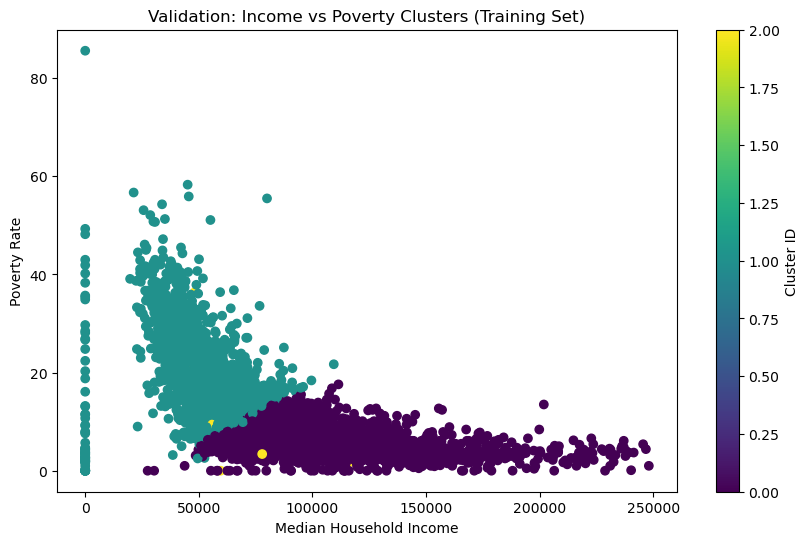

In [38]:
#do not need y_train because clustering is unsupervised

X_train, X_test = train_test_split(df_clean_unique, test_size=0.2, random_state=42)

scaler_t = StandardScaler()
t_scaled = scaler_t.fit_transform(X_train[cluster_features])
kmeans_t = KMeans(n_clusters=3, random_state=42).fit(t_scaled)

print("Cluster centers: ")
print(kmeans_t.cluster_centers_)

plt.figure(figsize=(10,6))
plt.scatter(X_train['Median Household Income'], X_train['Poverty Rate'], c=kmeans_t.labels_, cmap='viridis')
plt.xlabel('Median Household Income')
plt.ylabel('Poverty Rate')
plt.title('Median Household Income vs. Poverty Rate')
plt.colorbar(label='Cluster ID')

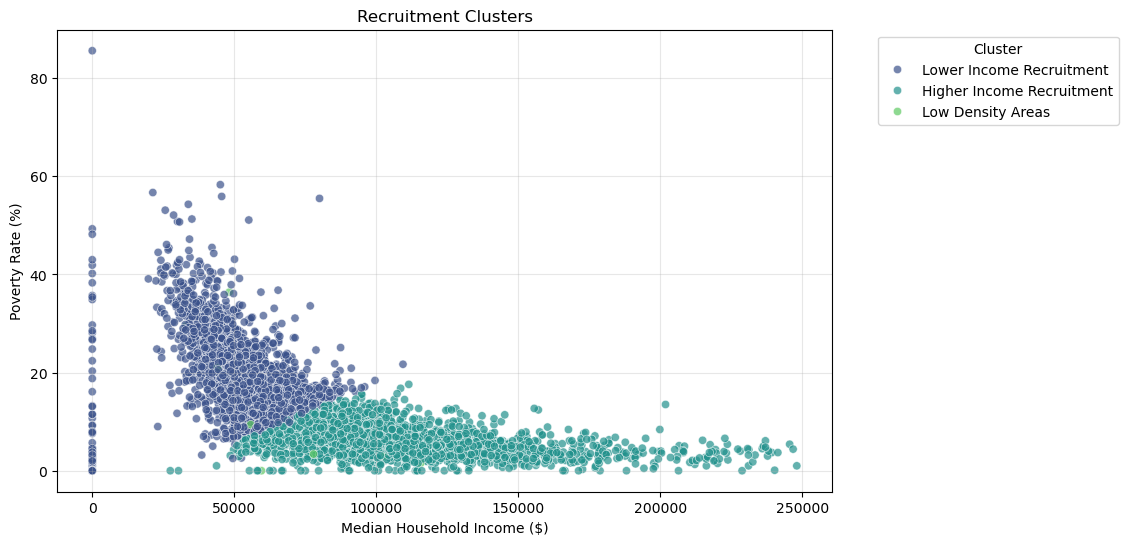

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

X_train['Cluster_ID'] = kmeans_t.labels_

id_means = X_train.groupby('Cluster_ID')['Median Household Income'].mean().sort_values()

rec_cluster_names = {
    id_means.index[0]: 'Lower Income Recruitment', 
    id_means.index[1]: 'Low Density Areas', 
    id_means.index[2]: 'Higher Income Recruitment'
}

X_train['Cluster_Label'] = X_train['Cluster_ID'].map(rec_cluster_names)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_train, 
    x='Median Household Income', 
    y='Poverty Rate', 
    hue='Cluster_Label',
    palette='viridis', 
    alpha=0.7
)

plt.title('Recruitment Clusters')
plt.xlabel('Median Household Income ($)')
plt.ylabel('Poverty Rate (%)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
trend_analysis = df_clean.groupby(['Season', 'Cluster_ID',]).size().unstack(fill_value=0)

trend_pct = trend_analysis.divide(trend_analysis.sum(axis=1), axis=0) * 100

print("-- % of Cities per Cluster by Season --")
print(trend_pct.round(2))

-- % of Cities per Cluster by Season --
Cluster_ID      0      1     2
Season                        
2020-2021   50.89  48.38  0.73
2021-2022   49.88  49.42  0.69
2022-2023   49.85  49.51  0.64
2023-2024   49.59  49.91  0.50
2024-2025   48.97  50.59  0.45


<h5>by season

In [41]:
cluster_names = {
    0: 'Lower Income Recruitment',
    1: 'Higher Income Recruitment', 
    2: 'Low Density Areas'
} #change cluster names

df_clean['Cluster_Name'] = df_clean['Cluster_ID'].map(cluster_names)

trend_named = df_clean.groupby(['Season', 'Cluster_Name']).size().unstack(fill_value=0)
print(trend_named)

Cluster_Name  Higher Income Recruitment  Low Density Areas  \
Season                                                       
2020-2021                          2060                 31   
2021-2022                          2135                 30   
2022-2023                          2153                 28   
2023-2024                          2175                 22   
2024-2025                          2157                 19   

Cluster_Name  Lower Income Recruitment  
Season                                  
2020-2021                         2167  
2021-2022                         2155  
2022-2023                         2168  
2023-2024                         2161  
2024-2025                         2088  


<h4> visualize

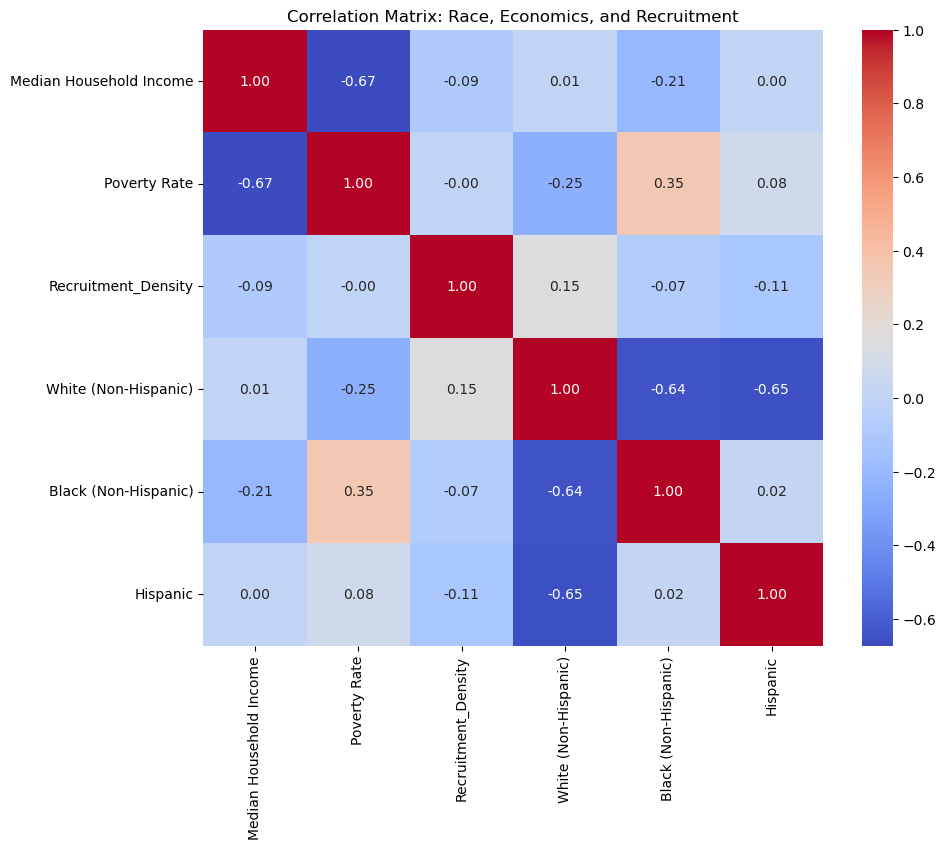

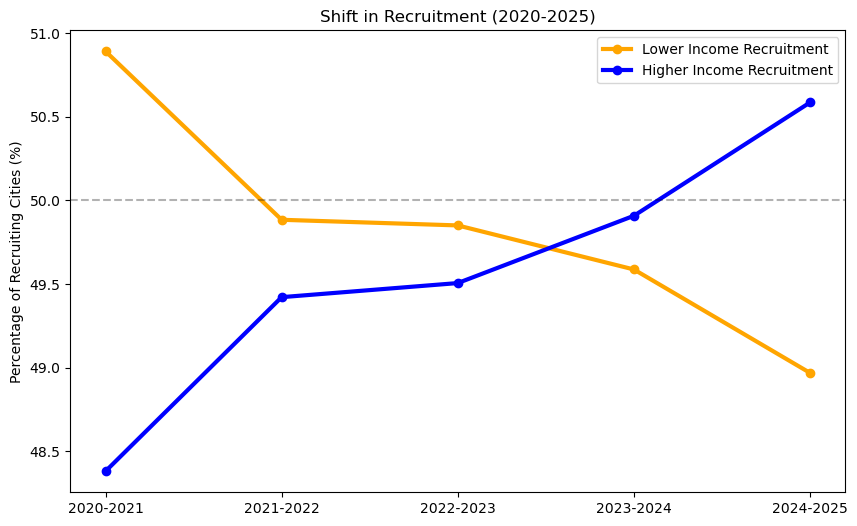

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
corr_cols = ['Median Household Income', 'Poverty Rate', 'Recruitment_Density', 
             'White (Non-Hispanic)', 'Black (Non-Hispanic)', 'Hispanic']

sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Race, Economics, and Recruitment')
plt.savefig('correlation_matrix.png')

trend_data = df_clean.groupby(['Season', 'Cluster_Name']).size().unstack(fill_value=0)
trend_pct = trend_data.divide(trend_data.sum(axis=1), axis=0) * 100

#change labels to match ^
plt.figure(figsize=(10, 6))
plt.plot(trend_pct.index, trend_pct['Lower Income Recruitment'], marker='o', label='Lower Income Recruitment', linewidth=3, color='orange')
plt.plot(trend_pct.index, trend_pct['Higher Income Recruitment'], marker='o', label='Higher Income Recruitment', linewidth=3, color='blue')
plt.axhline(50, color='black', linestyle='--', alpha=0.3) 
plt.title('Shift in Recruitment (2020-2025)')
plt.ylabel('Percentage of Recruiting Cities (%)')
plt.legend()
plt.savefig('seasonal_trend.png')

In [65]:
import numpy as np
from sklearn.linear_model import LinearRegression

seasons = np.array([2021, 2022, 2023, 2024, 2025]).reshape(-1, 1)
future_seasons = np.array([2026, 2027, 2028]).reshape(-1, 1)

predictions = {}

for cluster in trend_pct.columns:
    y = trend_pct[cluster].values
    
    model = LinearRegression()
    model.fit(seasons, y)
    
    future_vals = model.predict(future_seasons)
    predictions[cluster] = future_vals

print("--- 3-Year Recruitment Forecast ---")
for cluster, vals in predictions.items():
    print(f"{cluster}: 2026 est. {vals[0]:.2f}%, 2027 est. {vals[1]:.2f}%, 2028 est. {vals[2]:.2f}%")

--- 3-Year Recruitment Forecast ---
0: 2026 est. 48.59%, 2027 est. 48.18%, 2028 est. 47.76%
1: 2026 est. 51.03%, 2027 est. 51.52%, 2028 est. 52.01%
2: 2026 est. 0.38%, 2027 est. 0.30%, 2028 est. 0.23%


In [43]:
df_clean.head(5)

,City,State,Population (aged 15-19),Median Household Income,Poverty Rate,White (Non-Hispanic),Black (Non-Hispanic),American Indian/Alaskan Native (Non-Hispanic),Asian (Non-Hispanic),Hispanic,Season,Unique_Recruits,Recruitment_Density,Cluster_ID,Cluster_Name
0,Abbeville,Louisiana,681.0,34977.0,33.4,42.2,43.3,0.0,4.9,4.3,2020-2021,1,14.684288,0,Lower Income Recruitment
1,Abbeville,Louisiana,681.0,34977.0,33.4,42.2,43.3,0.0,4.9,4.3,2021-2022,1,14.684288,0,Lower Income Recruitment
2,Abbeville,Louisiana,681.0,34977.0,33.4,42.2,43.3,0.0,4.9,4.3,2024-2025,1,14.684288,0,Lower Income Recruitment
3,Abbottstown,Pennsylvania,21.0,72266.0,8.5,95.3,0.1,0.0,1.1,1.2,2020-2021,1,476.190476,1,Higher Income Recruitment
4,Abbottstown,Pennsylvania,21.0,72266.0,8.5,95.3,0.1,0.0,1.1,1.2,2021-2022,1,476.190476,1,Higher Income Recruitment


In [44]:
total_unique_recruits = final_df['Unique Player Key'].nunique()
avg_recruits_per_year = total_unique_recruits / 5  

us_teen_pop_2022 = 10683985 #acs 2022 - median 

national_baseline = (avg_recruits_per_year / us_teen_pop_2022) * 10000
print(f"National Annual Baseline: {national_baseline:.2f} per 10k")

df_clean['Recruitment_Density'] = ((df_clean['Unique_Recruits'] / 5) / df_clean['Population (aged 15-19)']) * 10000


National Annual Baseline: 4.74 per 10k


In [45]:
print(df_clean_unique.shape)
print(df_clean_unique['Unique_Recruits'].sum())

(6722, 14)
25304


In [46]:
df_clean['Desert_Score'] = df_clean['Poverty Rate'] / (df_clean['Recruitment_Density'] + 0.1)
df_clean_unique['Desert_Score'] = df_clean_unique['Poverty Rate'] / (df_clean_unique['Recruitment_Density'] + 0.1)

In [47]:
export_df = df_clean.copy()
export_df_unique = df_clean_unique.copy()

columns_to_export = [
    'City', 'State', 'Population (aged 15-19)', 'Season', 'Median Household Income', 'Poverty Rate', 
    'Recruitment_Density', 'Cluster_Name', 'White (Non-Hispanic)', 
    'Black (Non-Hispanic)', 'Hispanic', 'Asian (Non-Hispanic)', 'American Indian/Alaskan Native (Non-Hispanic)',
    'Unique_Recruits','Desert_Score'
]

columns_to_export_unique = [
    'City', 'State', 'Population (aged 15-19)', 'Median Household Income', 'Poverty Rate', 
    'Recruitment_Density', 'Cluster_Name', 'White (Non-Hispanic)', 
    'Black (Non-Hispanic)', 'Hispanic', 'Asian (Non-Hispanic)', 'American Indian/Alaskan Native (Non-Hispanic)',
    'Unique_Recruits','Desert_Score'
]

export_df[columns_to_export].to_csv('D1_Recruitment_Master_Data_final.csv', index=False)
print("Export Successful: D1_Recruitment_Master_Data_final.csv")

export_df_unique[columns_to_export_unique].to_csv('D1_Recruitment_Master_Data_unique.csv', index=False)
print("Export Successful: D1_Recruitment_Master_Data_unique.csv")

Export Successful: D1_Recruitment_Master_Data_final.csv
Export Successful: D1_Recruitment_Master_Data_unique.csv
